<img src="../img/GTK_Logo_Social_Icon.jpg" width=175 align="right" />

# Worksheet 13.5: Multi-Agent SOC Team-Answers
## Building a Collaborative Security Operations Center

**Estimated Time**: 60-90 minutes

### Learning Objectives
- Create specialized agents using `create_agent`
- Build a supervisor agent that delegates to specialists using `create_supervisor`
- Understand multi-agent handoffs and how agents collaborate
- Design agent teams that mirror real SOC team structures

### What You'll Build
A multi-agent system where a supervisor coordinates three specialist agents:

```
                    ┌─── Header Analyst (auth + sender checks)
Supervisor ────────────┼─── Content Analyst (text analysis)
                    └─── URL/Attachment Analyst (link + file checks)
```

### Real-World Parallel
In a real SOC, different analysts have different specialties. A Tier 1 analyst might focus on
initial triage, while specialists handle header analysis, malware reverse engineering, or threat
intelligence. Our multi-agent system mirrors this division of labor.

In [7]:
import os
from dotenv import load_dotenv, find_dotenv

# Load environment variables from .env file
load_dotenv(find_dotenv())

# Verify the API key is set
assert os.getenv("ANTHROPIC_API_KEY"), "ANTHROPIC_API_KEY not found! Create a .env file with your key."
print("Environment loaded successfully.")

Environment loaded successfully.


In [8]:
from langchain_anthropic import ChatAnthropic
from langchain.agents import create_agent
from langgraph_supervisor import create_supervisor

import sys
sys.path.insert(0, "..")
from utils.email_loader import load_emails, format_email_for_analysis
from utils.mock_tools import check_url_reputation, check_sender_reputation, check_email_authentication
from utils.display_helpers import display_graph_mermaid

print("All imports successful.")

All imports successful.


In [9]:
emails = load_emails(small=False)
print(f"Loaded {len(emails)} emails")

Loaded 50 emails


In [10]:
llm = ChatAnthropic(model="claude-opus-4-8", max_tokens=4096)
print(f"LLM initialized: {llm.model}")

LLM initialized: claude-opus-4-8


---
## Concept: Specialized Agents with `create_agent`

In previous labs, we built a single ReAct agent by hand -- defining nodes, routing functions,
and tool execution logic ourselves. LangChain provides `create_agent` as a **prebuilt
shortcut** that packages all of that into a single function call.

`create_agent` takes:
- **`model`**: The LLM to use
- **`tools`**: A list of tools the agent can call (can be empty if the agent relies on LLM reasoning alone)
- **`name`**: A unique identifier used by the supervisor for delegation
- **`prompt`**: A system prompt that defines the agent's specialty and behavior

It returns a fully functional ReAct agent with:
- A tool-calling loop (reason -> act -> observe -> repeat)
- Automatic tool execution
- Message-based state management

Each specialist agent is a **self-contained expert** -- it knows its domain, has the right tools,
and can work independently. The supervisor doesn't need to know *how* each agent works, only
*what* each agent specializes in.

In [11]:
# --- Header Analyst ---
# Specializes in email authentication and sender verification.
# Has access to check_sender_reputation and check_email_authentication tools.

header_analyst = create_agent(
    model=llm,
    tools=[check_sender_reputation, check_email_authentication],
    name="header_analyst",
    system_prompt="""You are a Header Analyst specializing in email authentication and sender verification.

Your job is to:
1. Check the sender's reputation using the sender reputation tool
2. Verify email authentication (SPF, DKIM, DMARC) using the authentication check tool
3. Assess whether the sender domain is legitimate or spoofed
4. Look for display name vs. email address mismatches

Provide a detailed analysis of your findings. Be specific about what you found and what it means for the email's legitimacy.""",
)

print("Header Analyst agent created.")

Header Analyst agent created.


In [12]:
# --- Content Analyst ---
# Specializes in analyzing email body text for social engineering and phishing patterns.
# No tools -- relies entirely on LLM reasoning.

content_analyst = create_agent(
    model=llm,
    tools=[],
    name="content_analyst",
    system_prompt="""You are a Content Analyst specializing in analyzing email text for social engineering and phishing patterns.

Your job is to analyze the email body for:
1. Urgency and pressure tactics ("immediately", "within 24 hours", "suspended")
2. Social engineering techniques (authority impersonation, fear, greed)
3. Requests for sensitive information (credentials, financial data, personal info)
4. Grammar and spelling quality
5. Tone inconsistencies (e.g., a "CEO" email that sounds unprofessional)
6. BEC (Business Email Compromise) patterns (wire transfers, gift cards, payroll changes)
7. Vishing attempts (phone numbers to call for "support")

Provide a detailed analysis of the email content. Be specific about which tactics you identified and rate the sophistication of any social engineering attempts.""",
)

print("Content Analyst agent created.")

Content Analyst agent created.


In [13]:
# --- URL/Attachment Analyst ---
# Specializes in link analysis and file-based threat detection.
# Has access to check_url_reputation tool.

url_analyst = create_agent(
    model=llm,
    tools=[check_url_reputation],
    name="url_attachment_analyst",
    system_prompt="""You are a URL and Attachment Analyst specializing in link analysis and file-based threat detection.

Your job is to:
1. Check each URL in the email against threat intelligence using the URL reputation tool
2. Identify suspicious URL patterns (lookalike domains, URL shorteners, mismatched display text)
3. Assess attachment risk based on file types (.exe, .xlsm, .docm, .zip are high risk)
4. Look for double extensions (e.g., document.pdf.exe)

Provide a detailed analysis of all URLs and attachments. Be specific about what you found and the risk level of each.""",
)

print("URL/Attachment Analyst agent created.")

URL/Attachment Analyst agent created.


---
## Concept: Supervisor Agent with `create_supervisor`

Now that we have three specialist agents, we need a **supervisor** to coordinate them.
The `create_supervisor` function from `langgraph_supervisor` creates an agent that:

1. **Receives** the initial investigation request (an email to analyze)
2. **Decides** which specialist(s) to consult based on the email content
3. **Delegates** work by sending messages to specialist agents
4. **Receives** specialist reports back
5. **Synthesizes** all findings into a final verdict

Key parameters:
- **`agents`**: The list of specialist agents the supervisor can delegate to
- **`prompt`**: Instructions that tell the supervisor how to manage the team
- **`output_mode`**: Controls what the final output includes:
  - `"full_history"` -- returns the complete message trace (useful for debugging and observing handoffs)
  - `"last_message"` -- returns only the supervisor's final summary

The supervisor is itself an LLM-powered agent. It uses tool calls internally to "hand off" to
specialists -- each specialist appears as a callable tool from the supervisor's perspective.
This is the **multi-agent handoff** pattern.

In [14]:
supervisor = create_supervisor(
    model=llm,
    agents=[header_analyst, content_analyst, url_analyst],
    prompt="""You are the SOC Team Lead supervising a team of email security analysts.

Your team:
- header_analyst: Checks email authentication (SPF/DKIM/DMARC) and sender reputation
- content_analyst: Analyzes email text for phishing language and social engineering
- url_attachment_analyst: Checks URL reputation and analyzes attachments

For each email investigation:
1. Review the email and determine which specialists to consult
2. Delegate to the relevant specialists (you may consult multiple)
3. After receiving their reports, synthesize the findings
4. Provide a final verdict: 'phishing', 'suspicious', or 'legitimate'
5. Include confidence level and key evidence from your team

Always consult at least 2 specialists for a thorough investigation. For emails with URLs, always consult the URL analyst. For emails with unusual senders, always consult the header analyst.""",
    output_mode="full_history",
)

# Compile the supervisor into a runnable graph
graph = supervisor.compile()
print("Multi-agent SOC team compiled!")

Multi-agent SOC team compiled!


### Lab 5: Multi-Agent SOC Team

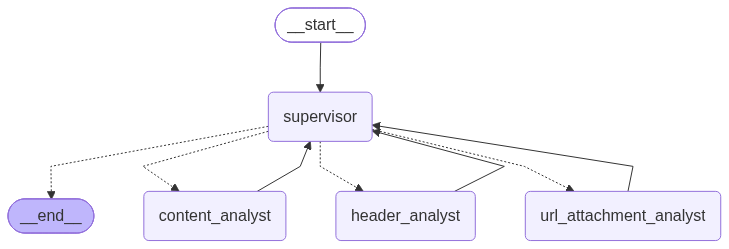

In [15]:
display_graph_mermaid(graph, "Lab 5: Multi-Agent SOC Team")

---
## Running Investigations

Now let's put the multi-agent team to work. We'll investigate several emails of different types
to observe how the supervisor routes work to different specialists and synthesizes their findings.

For each investigation, pay attention to:
- **Which specialists** the supervisor chooses to consult
- **What tools** each specialist uses
- **How the supervisor** combines the specialist reports into a final verdict

In [16]:
# --- Investigation 1: Credential Harvesting Phishing ---
# EMAIL-001 is a classic credential phishing email with a fake Microsoft login page.
# We expect the supervisor to consult the header analyst (spoofed sender),
# content analyst (urgency tactics), and URL analyst (malicious link).

email = [e for e in emails if e["id"] == "EMAIL-001"][0]
email_text = format_email_for_analysis(email)

print(f"Investigating: {email['id']} - {email['subject']}")
print(f"Ground truth: {email['ground_truth']}")
print("=" * 60)

result = graph.invoke({
    "messages": [
        {"role": "user", "content": f"Investigate this email for phishing:\n\n{email_text}"}
    ]
})

# Print the final supervisor summary
final_message = result["messages"][-1]
print("SOC Team Lead Final Report:")
print("=" * 60)
print(final_message.content)

Investigating: EMAIL-001 - URGENT: Your account has been compromised
Ground truth: phishing
SOC Team Lead Final Report:
The investigation is complete. All three specialists have reported, and I've synthesized their findings above.

**Bottom line:** EMAIL-001 is confirmed **PHISHING** with **very high confidence** — a Microsoft-impersonation credential-harvesting attack backed by a known phishing sender (142 reports), total authentication failure (0/3), a typosquatted lookalike domain, urgency-driven social engineering, and a threat-intel-confirmed malicious URL (98%). Recommended action: **block, quarantine, and warn the recipient.**


In [17]:
# --- Investigation 2: Business Email Compromise (BEC) ---
# EMAIL-006 is a BEC attempt -- an attacker impersonating a company executive.
# BEC emails often have fewer technical indicators (no malicious URLs),
# so the content analyst's social engineering detection is critical here.

email = [e for e in emails if e["id"] == "EMAIL-006"][0]
email_text = format_email_for_analysis(email)

print(f"Investigating: {email['id']} - {email['subject']}")
print(f"Ground truth: {email['ground_truth']}")
print("=" * 60)

result = graph.invoke({
    "messages": [
        {"role": "user", "content": f"Investigate this email for phishing:\n\n{email_text}"}
    ]
})

final_message = result["messages"][-1]
print("SOC Team Lead Final Report:")
print("=" * 60)
print(final_message.content)

Investigating: EMAIL-006 - Urgent wire transfer needed - CONFIDENTIAL
Ground truth: phishing
SOC Team Lead Final Report:
Both specialists have reported. Here is my consolidated final assessment.

---

# 🚨 FINAL VERDICT: PHISHING (Business Email Compromise / CEO Fraud)

**Email ID:** EMAIL-006
**Confidence Level:** 99% — CONFIRMED MALICIOUS

---

## Executive Summary
This is a textbook **CEO-fraud Business Email Compromise (BEC)** attack. An attacker is impersonating the CEO from a lookalike domain to pressure the accounting team into wiring **$47,500** to a fraudulent account. Both technical (header) and behavioral (content) evidence independently and conclusively confirm this is an attack.

---

## Key Evidence from the Team

### 🔴 Header Analyst — Technical Indicators (Critical)
| Signal | Finding |
|--------|---------|
| Sender reputation | **KNOWN PHISHING SENDER** — 23 abuse reports since 2025-06-13 |
| SPF / DKIM / DMARC | **ALL FAIL (0/3)** — spoofed, unauthenticated, unaligned 

In [18]:
# --- Investigation 3: Legitimate Email ---
# EMAIL-033 is a legitimate email. The multi-agent team should confirm
# that authentication passes, content is professional, and URLs are clean.

email = [e for e in emails if e["id"] == "EMAIL-033"][0]
email_text = format_email_for_analysis(email)

print(f"Investigating: {email['id']} - {email['subject']}")
print(f"Ground truth: {email['ground_truth']}")
print("=" * 60)

result = graph.invoke({
    "messages": [
        {"role": "user", "content": f"Investigate this email for phishing:\n\n{email_text}"}
    ]
})

final_message = result["messages"][-1]
print("SOC Team Lead Final Report:")
print("=" * 60)
print(final_message.content)

Investigating: EMAIL-033 - [company/app] Issue #291: Fix memory leak in connection pool
Ground truth: legitimate
SOC Team Lead Final Report:
# 🔍 SOC Investigation Summary — EMAIL-033

## Final Verdict: ✅ **LEGITIMATE**
### Confidence Level: **HIGH (~95%)**

---

## Investigation Overview
GitHub issue-notification email to `mike.jones@company.com`. I consulted the **Header Analyst** and **URL/Attachment Analyst** for a thorough review.

## Key Evidence from the Team

### 🔐 Header Analyst
- ✅ **Trusted sender:** `noreply@github.com` — official, verified GitHub notification address
- ✅ **Authentication 3/3:** SPF pass, DKIM pass, DMARC pass — rules out spoofing
- ✅ **No look-alike/typosquat domain**
- ✅ **Display name "GitHub" aligns** with the sending address

### 🔗 URL/Attachment Analyst
- ✅ **URL CLEAN** (95% confidence): `https://github.com/company/app/issues/291` resolves to the authentic, verified `github.com` domain over HTTPS
- ✅ **No masking, shorteners, or lookalike tricks** — d

In [19]:
# --- Investigation 4: Borderline / Suspicious Email ---
# EMAIL-049 is a borderline case that may not be clearly phishing or legitimate.
# This tests whether the multi-agent team can handle ambiguity.

email = [e for e in emails if e["id"] == "EMAIL-049"][0]
email_text = format_email_for_analysis(email)

print(f"Investigating: {email['id']} - {email['subject']}")
print(f"Ground truth: {email['ground_truth']}")
print("=" * 60)

result = graph.invoke({
    "messages": [
        {"role": "user", "content": f"Investigate this email for phishing:\n\n{email_text}"}
    ]
})

final_message = result["messages"][-1]
print("SOC Team Lead Final Report:")
print("=" * 60)
print(final_message.content)

Investigating: EMAIL-049 - Exclusive: Free Cloudflare Enterprise trial for your organization
Ground truth: suspicious
SOC Team Lead Final Report:
The investigation is complete. All three specialists have reported, and I've delivered the consolidated final verdict above:

**FINAL VERDICT: 🚨 PHISHING — HIGH CONFIDENCE**

The key evidence that led to this determination:
- **Lookalike domain** `cloudflare-partners.com` impersonating the real Cloudflare (`cloudflare.com`)
- **Threat intel flagged the URL** as potential phishing
- **SPF softfail** + unknown sender reputation
- **Misleading DMARC pass** (authenticates the attacker's own domain, not Cloudflare)
- **Classic social engineering** — exclusivity lure, artificial 7-day deadline, and link-based credential-harvesting payload

Recommended immediate actions: quarantine the email, block the domain across gateway/proxy/DNS, and alert users.


In [21]:
# --- Agent Handoff Trace ---
# Show the full handoff trace for the last investigation.
# This reveals the supervisor's delegation pattern: which agents were
# consulted, what tools they called, and how the conversation flowed.

print("Agent Handoff Trace:")
print("=" * 60)
for msg in result["messages"]:
    sender = getattr(msg, 'name', None) or msg.type
    content_preview = msg.content[:150] if msg.content else "(tool call)"
    tool_calls_info = ""
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        tool_calls_info = f" [calls: {', '.join(tc['name'] for tc in msg.tool_calls)}]"
    print(f"\n[{sender}]{tool_calls_info}")
    if msg.content:
        print(f"  {content_preview}...")

Agent Handoff Trace:

[human]
  Investigate this email for phishing:

Email ID: EMAIL-049
Timestamp: 2025-06-17T09:00:00Z
From: Cloudflare Partner Program <partner-program@cloudflare...

[supervisor] [calls: transfer_to_header_analyst]
  [{'text': "I'll investigate this email for phishing. The email contains a URL and uses a sender domain that mimics Cloudflare, so I'll consult multiple specialists. Let me delegate to all three analysts since there are relevant concerns for each.", 'type': 'text'}, {'id': 'toolu_014Fgj1UEAc8Tdf8pbSgAtDN', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'transfer_to_header_analyst', 'type': 'tool_use'}]...

[transfer_to_header_analyst]
  Successfully transferred to header_analyst...

[header_analyst] [calls: check_sender_reputation, check_email_authentication]
  [{'text': "Let me start my analysis by checking the sender's reputation and email authentication. These are independent checks, so I'll run them together.", 'type': 'text'}, {'id': 'toolu_013

---
## Bonus: Batch Processing

Process a larger set of emails to evaluate the multi-agent team's accuracy across different
email types. This gives a broader picture of how well the supervisor delegates and how
accurate the combined specialist analysis is.

In [ ]:
# Process a sample of 10 emails
import random
random.seed(42)
sample = random.sample(emails, 10)

for email in sample:
    email_text = format_email_for_analysis(email)
    result = graph.invoke({
        "messages": [
            {"role": "user", "content": f"Investigate this email for phishing:\n\n{email_text}"}
        ]
    })
    final = result["messages"][-1].content

    # Extract verdict from the response (best effort)
    verdict_guess = "unknown"
    for v in ["phishing", "suspicious", "legitimate"]:
        if v in final.lower():
            verdict_guess = v
            break

    match = "\u2713" if verdict_guess == email["ground_truth"] else "\u2717"
    print(f"{match} {email['id']}: predicted={verdict_guess}, actual={email['ground_truth']}")

✓ EMAIL-021: predicted=phishing, actual=phishing
✗ EMAIL-029: predicted=phishing, actual=legitimate
✓ EMAIL-026: predicted=legitimate, actual=legitimate


---
## Checkpoint Checklist

- [ ] All three specialist agents are created with appropriate tools and prompts
- [ ] Supervisor agent compiles and can delegate to specialists
- [ ] Graph visualization shows the supervisor-agent topology
- [ ] Supervisor delegates to relevant specialists based on email content
- [ ] Header analyst uses authentication and sender reputation tools
- [ ] Content analyst identifies social engineering tactics
- [ ] URL analyst checks URLs against threat intelligence
- [ ] Supervisor synthesizes specialist findings into a coherent verdict

## Congratulations!

You've completed all 5 labs! You've built:
1. **Lab 1**: A simple email classifier with structured output
2. **Lab 2**: A tool-calling investigation agent with ReAct loop
3. **Lab 3**: A tiered analysis pipeline with conditional routing
4. **Lab 4**: Human-in-the-loop review with interrupt/resume
5. **Lab 5**: A multi-agent SOC team with supervisor orchestration

These patterns (state management, tool use, routing, HITL, multi-agent) are the building blocks
for production AI security systems.